# Supplementary material - Physics-Informed Neural Networks with Dynamical Boundary Constraints

Andrés Martínez-Esteban $^{1,2}$, Pablo Calvo-Barlés $^{2,3}$, Luis Martin Moreno $^{2,3}$ and Sergio G Rodrigo $^{1,2,*}$

*$^1$ Departamento de Física Aplicada, Facultad de Ciencias, Universidad de Zaragoza, 50009 Zaragoza, Spain*

*$^2$ Instituto de Nanociencia y Materiales de Aragón (INMA), CSIC-Universidad de Zaragoza, 50009 Zaragoza, Spain*

*$^3$ Departamento de Física de la Materia Condensada, Universidad de Zaragoza, Zaragoza 50009, Spain*

$^*$ corresponding author: sergut@unizar.es

## Main libraries

In [1]:
# Tensorflow Keras and rest of the packages
import tensorflow as tf
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

## Definition of the PINN

### Example: the harmonic oscillator

$y''(x) + y(x)=0$

$y(0)=1, y'(0)=0$

*solution: $y(x) = cos(x)$*

The PINN takes values of $x$ as input and outputs the corresponding predictions for $y(x)$. The *standard* PINN loss function includes two terms, one for the differential equation ($L_D$),

\begin{equation}
L_D=\frac{1}{N}\sum_{i=1}^N\left(\frac{dy_{NN}^2}{dx^2}(x_i)+y_{NN}(x_i) \right)^2,
\end{equation}

and another for the initial conditions ($L_{IC}$),

\begin{equation}
L_{IC}=(y_{NN}(x_0)-y(x_0))^2+(\frac{dy_{NN}}{dx}(x_0)-\frac{dy}{dx}(x_0))^2.
\end{equation}

The subscript NN indicates the predictions made by the PINN. $L_D$ is evaluated at a set of $N$ distinct points $x_i$, which corresponds to the training data.  In the loss for the initial conditions, the output of the PINN is evaluated at the coordinate corresponding to the initial conditions, $x_0$.

The loss term corresponding to the DBCs is given by:
\begin{align}
&L_{DBC}=\sum_{\alpha=1}^{N_{DBC}}(y_{NN}(\hat X_{\alpha})-\hat Y_\alpha)^2,
\end{align}
where $\hat Y_\alpha$ is the saved PINN prediction at the endpoint $\hat X_\alpha$ of the $\alpha$‑th training interval, which we refer to as a DBC, and $N_{DBC}$ is the number of DBCs.

DBCs can be naturally combined with other techniques aimed at enhancing PINN performance. The notebook includes the gradient-enhanced PINN (gPINN) method [Computer Methods in Applied Mechanics and Engineering 393, 114823 (2022)]. For the harmonic oscillator example, this results in an additional loss term,
\begin{equation}
L_g=\frac{dL_D}{dx}=\frac{1}{N}\sum_{i=1}^N\left(\frac{dy_{NN}^3}{dx^3}(x_i)+\frac{dy_{NN}}{dx}(x_i) \right)^2.
\end{equation}

In [ ]:
class ODE_gPINN(tf.keras.Model):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.loss_ic_y = tf.keras.metrics.Mean(name="loss_ic_y")
        self.loss_ic_dy = tf.keras.metrics.Mean(name="loss_ic_dy")
        self.loss_ode = tf.keras.metrics.Mean(name="loss_ode")
        self.loss_grad = tf.keras.metrics.Mean(name="loss_grad")
        self.loss_dbc=tf.keras.metrics.Mean(name="loss_dbc")
        
        # Initialize x_dbc and y_dbc to None
        self.x_dbc = None
        self.y_dbc = None        

    def add_dynamic_boundary_condition(self, x_dbc, y_dbc):
        if not x_dbc and not y_dbc:
            tf.print("No dynamic boundary conditions provided. Skipping addition.")
        else:            
            # Convert inputs to tf.constant if they are not already
            x_dbc_tensor = tf.constant(x_dbc, dtype=tf.float32)
            y_dbc_tensor = tf.constant(y_dbc, dtype=tf.float32)

            # Initialize if self.x_dbc does not exist yet
            self.x_dbc = x_dbc_tensor
            self.y_dbc = y_dbc_tensor      
            
            tf.print("Dynamic boundary conditions added. Total points:", tf.shape(self.x_dbc)[0])
            tf.print("x_dbc:", self.x_dbc)
            tf.print("y_dbc:", self.y_dbc)

    def train_step(self, data):
        # Training points and exact solution
        x, y_exact = data

        # Initial conditions
        x0 = tf.constant([0.0], dtype=tf.float32)
        y0_exact = tf.constant([1.0], dtype=tf.float32)
        dy_dx0_exact = tf.constant([0.0], dtype=tf.float32)

        A = tf.constant([1.0], dtype=tf.float32)  # harmonic oscillator parameter

        with tf.GradientTape() as tape:
            # ---------- Initial condition gradients ----------
            with tf.GradientTape() as tape_ic:
                tape_ic.watch(x0)
                y0_NN = self(x0, training=False)
            dy_dx0_NN = tape_ic.gradient(y0_NN, x0)

            # ---------- Physics gradients ----------
            with tf.GradientTape(persistent=True) as tape_p:
                tape_p.watch(x)
                y_NN = self(x, training=False)

                dy_dx_NN   = tape_p.gradient(y_NN, x)
                d2y_dx2_NN = tape_p.gradient(dy_dx_NN, x)
                d3y_dx3_NN = tape_p.gradient(d2y_dx2_NN, x)

            # ---------- Shape safety ----------
            y0_exact       = tf.reshape(y0_exact, y0_NN.shape)
            dy_dx0_exact   = tf.reshape(dy_dx0_exact, dy_dx0_NN.shape)

            dy_dx_NN   = tf.reshape(dy_dx_NN, y_NN.shape)
            d2y_dx2_NN = tf.reshape(d2y_dx2_NN, y_NN.shape)
            d3y_dx3_NN = tf.reshape(d3y_dx3_NN, y_NN.shape)

            # ---------- Loss terms ----------
            loss_ic_y = self.compiled_loss(y0_NN, y0_exact)
            loss_ic_dy = self.compiled_loss(dy_dx0_NN, dy_dx0_exact)
            loss_ic = loss_ic_y + loss_ic_dy

            # Harmonic oscillator ODE
            loss_ode = self.compiled_loss(d2y_dx2_NN, -A * y_NN)

            # Third-derivative constraint for gradient-enhanced loss
            loss_grad = self.compiled_loss(d3y_dx3_NN, -A * dy_dx_NN)

            # Loss Dynamical Boundary Conditions
            if self.x_dbc is not None and self.y_dbc is not None:            
              y_NN_dbc = self(self.x_dbc, training=False)
              loss_dbc=self.compiled_loss(y_NN_dbc,self.y_dbc)
            else:
              loss_dbc=0.0

            # Total loss (optionally weight loss_grad)
            loss = loss_ic + loss_ode + loss_dbc + loss_grad

            del tape_p  # IMPORTANT

        # ---------- Optimization ----------
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        # ---- Update metrics ----
        self.loss_ic_y.update_state(loss_ic_y)
        self.loss_ic_dy.update_state(loss_ic_dy)
        self.loss_ode.update_state(loss_ode)
        self.loss_grad.update_state(loss_grad)
        self.loss_dbc.update_state(loss_dbc)        

        return {
            "loss": loss,
            "loss_ic_y": self.loss_ic_y.result(),
            "loss_ic_dy": self.loss_ic_dy.result(),
            "loss_ode": self.loss_ode.result(),
            "loss_grad": self.loss_grad.result(),
            "loss_dbc":self.loss_dbc.result()
        }

## Set the domain, define the model, loss, optimizer and callbacks

In [3]:
xmin = 0
xmax = 20.0
n_train = 10*int(xmax)

# Definition of the function domain
x_train=np.linspace(xmin,xmax,n_train)

# The solution y(x) for training and validation datasets
x0=0.0
y_train= np.cos(x_train)

# Input and output neurons (from the data)
input_neurons  = 1
output_neurons = 1

# Hiperparameters
epochs = 5000

# Definition of the model architecture (symbolic)
activation='tanh'
initializer = tf.keras.initializers.GlorotUniform(seed=5)
input = Input(shape=(input_neurons,))
x = Dense(500, activation=activation, kernel_initializer=initializer)(input)
x = Dense(500, activation=activation, kernel_initializer=initializer)(x)
x = Dense(500, activation=activation, kernel_initializer=initializer)(x)
output = Dense(output_neurons, kernel_initializer=initializer, activation=None)(x)

# Definition of the metrics, optimizer and loss
loss=tf.keras.losses.MeanSquaredError()
metrics=tf.keras.metrics.MeanSquaredError()
optimizer_fn= Adam(learning_rate=0.00001)

# Just use `fit` as usual
callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=1000,
                                            restore_best_weights=True)

## Train the model

In [4]:
NDBC=3 # Last point of the training data is added as a dynamic boundary condition every NDBC iterations
       # Last point is xmax

segment_length = n_train // NDBC
print(segment_length)

dbc_x_points = []
dbc_y_points = []
history_dbc = []

# Create a new model instance for each segment to reset weights and optimizer state
for i in range(NDBC):
  model=ODE_gPINN(inputs=input, outputs=output)
  model.compile(loss=loss,
            optimizer=optimizer_fn # Removed metrics=[metrics] argument
            )

  model.add_dynamic_boundary_condition(dbc_x_points, dbc_y_points)

  if (i==0):
    model.summary()

  # Calculate the end index for the current segment
  end_index = (i + 1) * segment_length

  # Create the x_train_segment and y_train_segment
  # Ensure all points are included in the last segment
  if i == NDBC - 1:
    x_train_segment = x_train
    y_train_segment = y_train
  else:
    x_train_segment = x_train[0:end_index]
    y_train_segment = y_train[0:end_index]

  # Reshape x_train_segment for the model input (expected shape: (samples, features))
  x_train_segment = x_train_segment.reshape(-1, 1)

  print(f"Training with {len(x_train_segment)} data points in iteration {i+1}/{NDBC}")
  history=model.fit(x_train_segment, y_train_segment, batch_size=1, epochs=epochs,
                  callbacks=callback,verbose=2)

  y_train_segment_dbc=model.predict(x_train_segment[-1])[0]
  dbc_x_points.append(x_train_segment[-1])
  dbc_y_points.append(y_train_segment_dbc)

  history_dbc.append(history)

66
No dynamic boundary conditions provided. Skipping addition.
Model: "ode_g_pinn"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 1)]               0         
_________________________________________________________________
dense (Dense)                (None, 500)               1000      
_________________________________________________________________
dense_1 (Dense)              (None, 500)               250500    
_________________________________________________________________
dense_2 (Dense)              (None, 500)               250500    
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 501       
_________________________________________________________________
loss_ic_y (Mean)             multiple                  2         
___________________________________________________________

## Evolution of losses during training

### Plot

['loss', 'loss_ic_y', 'loss_ic_dy', 'loss_ode', 'loss_grad', 'loss_dbc']


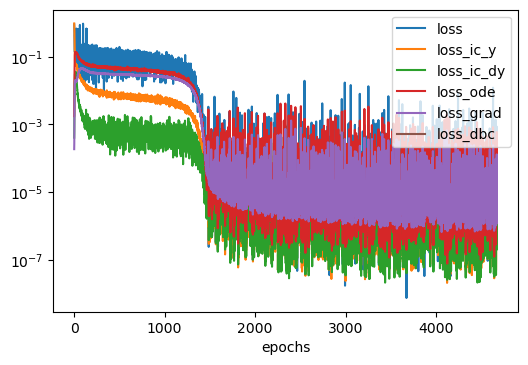

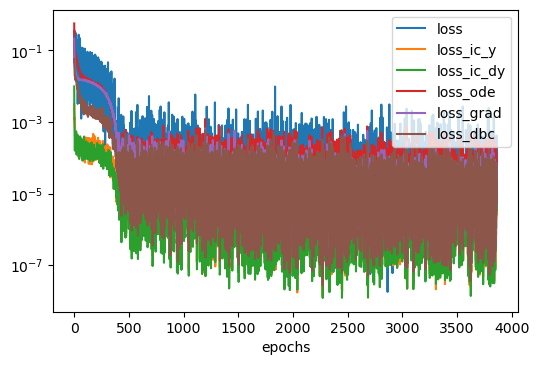

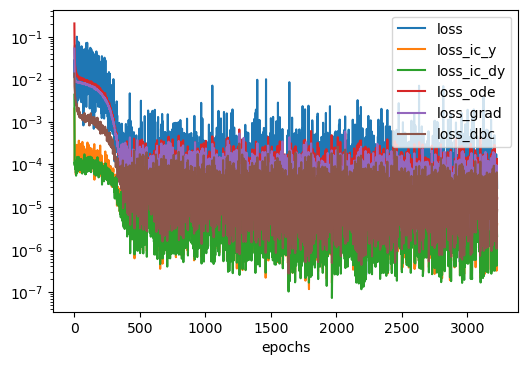

In [5]:
# summarize history for loss and metris
labels=list(history_dbc[0].history)
print(labels)
plt.rcParams['figure.dpi'] = 100
for segment,history in enumerate(history_dbc):
  for metrics in history.history:
      plt.plot(history.history[metrics],label=metrics)
  plt.yscale("log")
  plt.xlabel('epochs')
  plt.legend(loc='upper right')
  plt.savefig("losses dbd="+str(segment)+".png", dpi=150, bbox_inches='tight')
  plt.show()

### Save Dynamic Boundary Condition locations

In [6]:
import pandas as pd
df_dbc_points = pd.DataFrame({
    "x_dbc": dbc_x_points,
    "y_dbc": dbc_y_points
})
filename_dbc = "dynamic_boundary_conditions.csv"
df_dbc_points.to_csv(filename_dbc, index=False)
print(f"Saved dynamic boundary conditions to {filename_dbc}")
display(df_dbc_points.head())

Saved dynamic boundary conditions to dynamic_boundary_conditions.csv


,x_dbc,y_dbc
0,[6.532663316582915],[0.9689864]
1,[13.165829145728644],[0.8241824]
2,[20.0],[0.40658787]


### Save training losses

In [7]:
import pandas as pd

# pick loss-related keys from history.history (fallback to all keys)
keys = [k for k in history.history.keys() if "loss" in k.lower()]
if not keys:
    keys = [k for k in history.history.keys() if "mse" in k.lower()]
if not keys:
    keys = list(history.history.keys())

df_losses = pd.DataFrame({k: history.history[k] for k in keys})
df_losses.index = df_losses.index + 1  # epoch numbers starting at 1
df_losses.index.name = "epoch"

filename = "training_losses.csv"
df_losses.to_csv(filename)
print(f"Saved {len(df_losses.columns)} columns to {filename}")
df_losses.head()

Saved 6 columns to training_losses.csv


,loss,loss_ic_y,loss_ic_dy,loss_ode,loss_grad,loss_dbc
epoch,,,,,,
1,0.027646,0.002051,0.004331,0.203544,0.052410,0.013572
2,0.016042,0.000630,0.000417,0.058091,0.025463,0.006711
3,0.010805,0.000123,0.000095,0.041893,0.017735,0.006142
4,0.035542,0.000120,0.000115,0.032685,0.013658,0.005240
5,0.061922,0.000199,0.000103,0.025962,0.011856,0.004518


## Solution and its derivatives

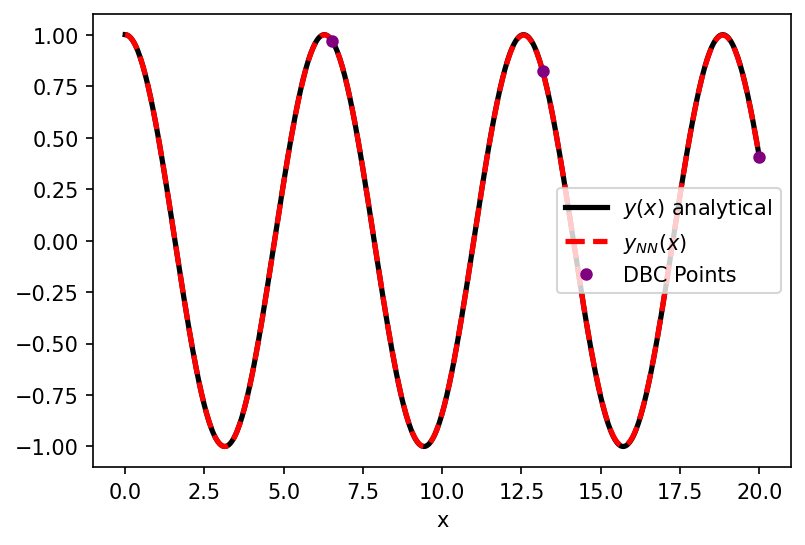

In [8]:
# Check the PINN at different points not included in the training set
n = 500
x=np.linspace(xmin,xmax,n)
x0=0.0
y_exact= np.cos(x)
y_NN=model.predict(x)

# The gradients (y'(x) and y''(x)) from the model
x_tf = tf.convert_to_tensor(x, dtype=tf.float32)
with tf.GradientTape(persistent=True) as t:
  t.watch(x_tf)
  with tf.GradientTape(persistent=True) as t2:
        t2.watch(x_tf)
        y = model(x_tf)
  dy_dx_NN = t2.gradient(y, x_tf)
d2y_dx2_NN = t.gradient(dy_dx_NN, x_tf)

# Plot the results
plt.rcParams['figure.dpi'] = 150
plt.plot(x, y_exact,color="black",linestyle='solid',
                     linewidth=2.5,label="$y(x)$ analytical")
plt.plot(x, y_NN, color="red",linestyle='dashed',
                     linewidth=2.5, label="$y_{NN}(x)$")
plt.plot(np.squeeze(dbc_x_points),np.squeeze(dbc_y_points), marker='o', linestyle='None', color='purple', markersize=5, label='DBC Points')
'''
plt.plot(x, dy_dx_NN,color="blue",linestyle='-.',
                     linewidth=3.0, label="$y'_{NN}(x)$")
plt.plot(x, d2y_dx2_NN,color="green", linestyle='dotted',
                     linewidth=3.0, label="$y''_{NN}(x)$")
'''
plt.legend()
plt.xlabel("x")
plt.savefig("y_vs_yNN.png", dpi=150, bbox_inches='tight')  # save figure as image
plt.show()

### Save solutions

In [9]:
import pandas as pd

# Flatten y_NN if needed (it's (500,1)), y_exact is already 1D
y_NN_flat = y_NN.flatten()

df_results = pd.DataFrame({
    "x": x,
    "y_exact": y_exact,
    "y_NN": y_NN_flat
})

filename = "y_exact_vs_y_NN.csv"
df_results.to_csv(filename, index=False)  # no index column in CSV
print(f"Saved y_exact and y_NN to {filename}")
df_results.head()


Saved y_exact and y_NN to y_exact_vs_y_NN.csv


,x,y_exact,y_NN
0,0.000000,1.000000,0.999971
1,0.040080,0.999197,0.999166
2,0.080160,0.996789,0.996759
3,0.120240,0.992780,0.992751
4,0.160321,0.987176,0.987150
